# Rice Variety Classification

## B104 Artificial Intelligence & Machine Learning
## Divakar Sabarwal GH1047352

### Github link for the project : 

https://github.com/sabarwaldivakar/Machine-Learning-Project

## 1. Data Exploration

### Business problem and data


The dataset contains the data about 2 types of Turkish rice grains. My aim is to make a model which can determine the type of rice from different aspects of the grain such as shape, measurements so that it can help in the sorting of the grains before packaging. So the Business Problem is: 
Can a rice processor identify **Cammeo** and **Osmancik** grains from their shapes and measurements to support sorting before packaging? This is binary classification: one row is one grain; `Class` is its variety. 
**Potential benefits** are fewer variety mix-ups and less manual classification. Actual savings are not measured, and the target does not identify damage or food safety.

The dataset was downloaded from Kaggle and is also available on UCI machine learning repository both the links are provided in the references. 


### Importing the required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Load and split first

The dataset is loaded and read with pandas.

In [2]:
df = pd.read_csv("data/Rice_data_type.csv",
                 skipinitialspace = True) 
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())
print(df.dtypes)

Columns: ['Unnamed: 0', 'Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent', 'Class']
Unnamed: 0             int64
Area                 float64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area          float64
Extent               float64
Class                 object
dtype: object


So the dataset has 9 total columns, 7 predictor features, 1 target 'Class' and 1 Unnamed:0, out of which we do not need the Unnamed:0 column because it is just an exported row index. So I dropped it and also then split the data into test and training data keeping the 20% dataset for test and the rest for training.

In [3]:
# splitting the data into training and testing sets
Target = "Class"

X = df.drop(columns=[Target, "Unnamed: 0"])
Y = df[Target]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42,
)

train_df = X_train.copy()
train_df[Target] = Y_train

print("training rows:", len(train_df))
print("Test rows:", len(X_test))

training rows: 3048
Test rows: 762


### Check class imbalance

Counted each class and calculated the accuracy of always predicting the majority variety.

,Count,Percentage
Class,,
b'Osmancik',1768,58.01
b'Cammeo',1280,41.99


Majority/minority ratio: 1.38
Majority-only training accuracy: 58.01 %


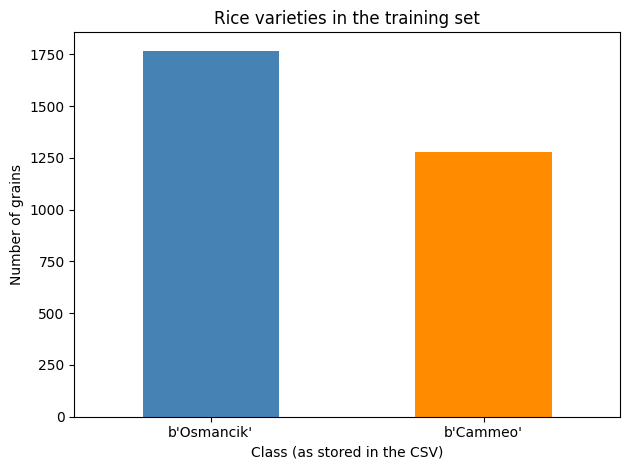

In [4]:
from IPython.display import display

class_counts = train_df[Target].value_counts()
class_percentages = train_df[Target].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
}))
print("Majority/minority ratio:", round(class_counts.max() / class_counts.min(), 2))
print("Majority-only training accuracy:", round(class_percentages.max(), 2), "%")

class_counts.plot.bar(color=["steelblue", "darkorange"], rot=0)
plt.title("Rice varieties in the training set")
plt.xlabel("Class (as stored in the CSV)")
plt.ylabel("Number of grains")
plt.tight_layout()
plt.show()

The training set has **1,768 Osmancik grains (58.01%)** and **1,280 Cammeo grains (41.99%)**. Started without resampling because the classes were already balanced and assessed both classes during validation. The labels in the plot contain the exact style of the text as in the dataset, such as `b'Cammeo'`.

### Inspecting training data quality

In [5]:
display(train_df.head())
train_df.info()

print("Missing values by column:")
print(train_df.isna().sum())
print("Duplicate training rows:", train_df.duplicated().sum())
print("Duplicate predictor rows:", X_train.duplicated().sum())

# Verify the excluded index using training rows only.
print("Exported index matches row positions:",
      df.loc[X_train.index, "Unnamed: 0"].eq(X_train.index).all())

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
3644,12529.0,437.838989,174.861450,92.189262,0.849733,12840.0,0.766019,b'Osmancik'
3418,11051.0,424.976013,180.871902,78.267380,0.901527,11240.0,0.568058,b'Osmancik'
1351,12975.0,463.851013,196.423965,85.064117,0.901363,13358.0,0.609126,b'Cammeo'
3591,10398.0,405.678986,162.227158,82.393456,0.861422,10658.0,0.644717,b'Osmancik'
246,14541.0,492.785004,204.257141,92.471016,0.891653,14893.0,0.758292,b'Cammeo'


<class 'pandas.core.frame.DataFrame'>
Index: 3048 entries, 3644 to 3174
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3048 non-null   float64
 1   Perimeter          3048 non-null   float64
 2   Major_Axis_Length  3048 non-null   float64
 3   Minor_Axis_Length  3048 non-null   float64
 4   Eccentricity       3048 non-null   float64
 5   Convex_Area        3048 non-null   float64
 6   Extent             3048 non-null   float64
 7   Class              3048 non-null   object 
dtypes: float64(7), object(1)
memory usage: 214.3+ KB
Missing values by column:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64
Duplicate training rows: 0
Duplicate predictor rows: 0
Exported index matches row positions: True


In [6]:
display(X_train.describe().round(3))

print("Infinite values:", X_train.isin([float("inf"), -float("inf")]).sum().sum())
size_columns = ["Area", "Perimeter", "Major_Axis_Length",
                "Minor_Axis_Length", "Convex_Area"]
print("Non-positive size measurements:", (X_train[size_columns] <= 0).sum().sum())
print("Eccentricity outside 0 to 1:",
      (~X_train["Eccentricity"].between(0, 1)).sum())
print("Extent outside 0 to 1:",
      (~X_train["Extent"].between(0, 1)).sum())
print("Major axis shorter than minor axis:",
      (X_train["Major_Axis_Length"] < X_train["Minor_Axis_Length"]).sum())
print("Convex area smaller than area:",
      (X_train["Convex_Area"] < X_train["Area"]).sum())

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3048.000,3048.000,3048.000,3048.000,3048.000,3048.000,3048.000
mean,12654.560,453.843,188.547,86.327,0.887,12938.381,0.663
std,1737.746,35.677,17.495,5.741,0.021,1782.390,0.077
min,7833.000,359.100,145.264,63.565,0.777,8015.000,0.497
25%,11363.000,425.492,174.168,82.702,0.872,11616.500,0.600
50%,12406.000,448.386,185.402,86.462,0.889,12678.500,0.647
75%,13921.500,483.052,203.274,90.167,0.902,14266.250,0.729
max,18913.000,547.215,239.010,107.542,0.948,19099.000,0.861


Infinite values: 0
Non-positive size measurements: 0
Eccentricity outside 0 to 1: 0
Extent outside 0 to 1: 0
Major axis shorter than minor axis: 0
Convex area smaller than area: 0


The inspection tells that all seven predictors are numerical and the Target,'Class' is categorical, and all are **without any missing values or duplicate training rows**. And the dataset was further checked for infinite values, zero or negative values, Eccentricity and Extent values lying in the range of 0 and 1. All these checks were necessary to avoid errors later in testing the model. These checks just show that the dataset is consistent. 

### Feature distributions and relationships

The following Histograms show ranges and shapes
 



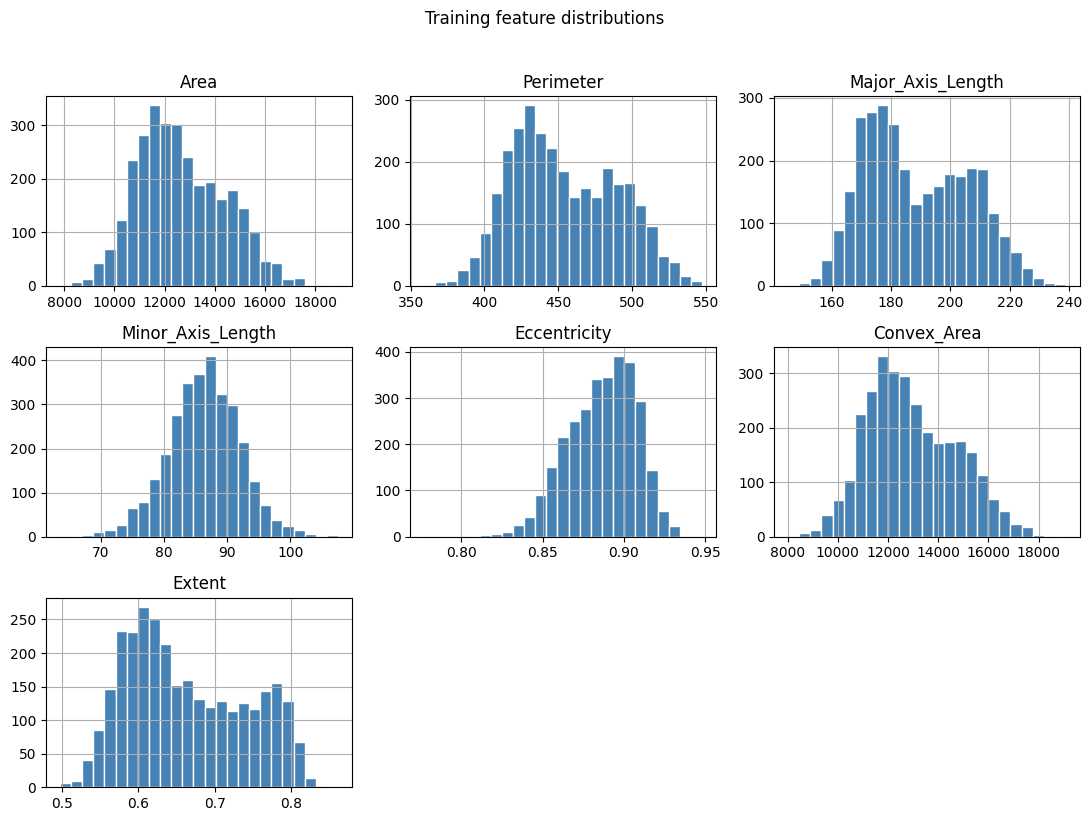

In [7]:
X_train.hist(bins=25, figsize=(11, 8), color="steelblue", edgecolor="white")
plt.suptitle("Training feature distributions", y=1.02)
plt.tight_layout()
plt.show()

The scatter plot compares varieties 



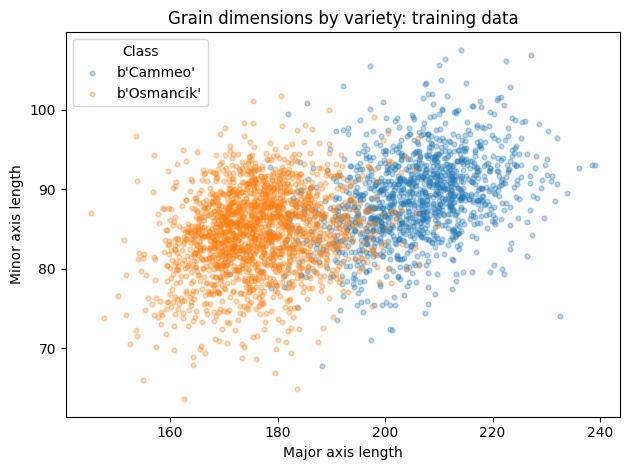

In [8]:
for label, group in train_df.groupby(Target):
    plt.scatter(group["Major_Axis_Length"], group["Minor_Axis_Length"],
                label=label, alpha=0.3, s=12)

plt.title("Grain dimensions by variety: training data")
plt.xlabel("Major axis length")
plt.ylabel("Minor axis length")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

The correlations reveal related measurements.

In [9]:
display(X_train.corr().round(3))

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
Area,1.000,0.967,0.903,0.788,0.352,0.999,-0.051
Perimeter,0.967,1.000,0.972,0.630,0.545,0.970,-0.123
Major_Axis_Length,0.903,0.972,1.000,0.452,0.710,0.904,-0.134
Minor_Axis_Length,0.788,0.630,0.452,1.000,-0.292,0.787,0.078
Eccentricity,0.352,0.545,0.710,-0.292,1.000,0.353,-0.204
Convex_Area,0.999,0.970,0.904,0.787,0.353,1.000,-0.056
Extent,-0.051,-0.123,-0.134,0.078,-0.204,-0.056,1.000


### Implications for modelling

- **Scale:** Area is in the thousands; Eccentricity and Extent are below one. Standardisation is important for KNN distances.
- **Redundancy:** Area and Convex_Area correlate at about **0.999**. This complicates coefficient interpretation but does not alone justify deleting a feature.
- **Cleaning:** no imputation is justified; simplified label formatting. Do not discard extreme but valid grains automatically.
- **Metrics:** select by **macro-F1**, giving both varieties equal weight. Also reported per-class precision/recall, confusion matrix, and accuracy. This assumes no known difference in misclassification costs.
- **Sampling:** batch independence and performance on new harvests/equipment are unverified. The random split assesses held-out grains from this collection.

The test set remains reserved until Model Evaluation.

## 2. Data Pre-processing

The training checks found no missing, infinite, duplicate, or physically inconsistent measurements. We therefore keep all training rows: no imputation or outlier removal is justified. The raw CSV stays unchanged.

The exported index was excluded during the split. We now map the two byte-style label strings directly to the binary integer style labels: **Osmancik = 0; Cammeo = 1**. This is target encoding, not an ordering of predictors. The same fixed mapping will be applied to test labels only during evaluation.

The 58:42 split does not by itself justify oversampling. We retain the natural distribution and check both classes through validation and final per-class metrics.

In [10]:
label_map = {"b'Osmancik'": 0, "b'Cammeo'": 1}
y_train = Y_train.map(label_map)

assert y_train.notna().all(), "Unexpected training labels: check the mapping."
print("Training label counts (0 = Osmancik, 1 = Cammeo):")
print(y_train.value_counts().sort_index())

Training label counts (0 = Osmancik, 1 = Cammeo):
Class
0    1768
1    1280
Name: count, dtype: int64


## 3. Feature Engineering

Kept all seven numerical measurements; no predictor one-hot encoding is needed. **Standardisation** puts their different units on comparable scales for KNN distances.

A `Pipeline` joins scaling and the classifier. In cross-validation it fits a fresh scaler on each fold's training rows, then transforms validation rows without learning from them. Defined the scaler here and fit it with the models in Model Training section 4.

PCA is not used because the dataset is really small with only 9 total columns out of which only 7 predictor features are being used to predict, computational cost is low, and the business interpretation is supported by retaining the original measurements. Original features preserve business meaning. Regularisation can constrain large coefficients, but cannot make almost-redundant Area and Convex_Area effects independently reliable.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # Defined here; fitted within each training fold.

## 4. Model Training

### Candidates and validation design

- **Majority baseline:** always chooses the most frequent training class; `DummyClassifier` implements this benchmark.
- **Logistic regression:** a linear decision boundary with inspectable coefficients; L2 regularisation limits complexity.
- **KNN:** a flexible local boundary that may overfit with few neighbours.

Use identical shuffled **five-fold cross-validation** splits inside the 80% training portion, checking class support. Tune `C = [0.01, 0.1, 1, 10, 100]` for logistic regression and `k = [3, 5, 11, 21, 41]` for KNN; keep Euclidean distance and uniform voting fixed.

Selected the highest mean validation macro-F1, using logistic regression for an exact tie. Fold SD is descriptive, not a confidence interval. These small grids are not exhaustive optimisation. In scikit-learn, larger `C` means **weaker** regularisation, opposite to the slides' penalty multiplier. The iteration limit allows convergence.

In [12]:
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

cv = KFold(n_splits=5, shuffle=True, random_state=42)

fold_counts = []
for fold, (fit_rows, valid_rows) in enumerate(cv.split(X_train), start=1):
    fold_counts.append({
        "Fold": fold,
        "Fit Osmancik": (y_train.iloc[fit_rows] == 0).sum(),
        "Fit Cammeo": (y_train.iloc[fit_rows] == 1).sum(),
        "Validation Osmancik": (y_train.iloc[valid_rows] == 0).sum(),
        "Validation Cammeo": (y_train.iloc[valid_rows] == 1).sum()
    })
display(pd.DataFrame(fold_counts))

baseline = DummyClassifier(strategy="most_frequent")
baseline_scores = cross_val_score(
    baseline, X_train, y_train, cv=cv, scoring="f1_macro"
)

logistic = Pipeline([
    ("scale", scaler),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])
knn = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(metric="euclidean"))
])

,Fold,Fit Osmancik,Fit Cammeo,Validation Osmancik,Validation Cammeo
0,1,1399,1039,369,241
1,2,1410,1028,358,252
2,3,1417,1021,351,259
3,4,1428,1011,340,269
4,5,1418,1021,350,259


In [13]:
logistic_search = GridSearchCV(
    logistic, {"model__C": [0.01, 0.1, 1, 10, 100]},
    cv=cv, scoring="f1_macro", return_train_score=True, error_score="raise"
)
knn_search = GridSearchCV(
    knn, {"model__n_neighbors": [3, 5, 11, 21, 41]},
    cv=cv, scoring="f1_macro", return_train_score=True, error_score="raise"
)

logistic_search.fit(X_train, y_train)
knn_search.fit(X_train, y_train)

# Display every setting, including its training and validation performance.
for name, search in [("Logistic regression", logistic_search), ("KNN", knn_search)]:
    print(name)
    results = pd.DataFrame(search.cv_results_)
    display(results[["params", "mean_train_score", "mean_test_score",
                     "std_test_score"]].round(4))

comparison = pd.DataFrame({
    "Model": ["Majority baseline", "Logistic regression", "KNN"],
    "CV macro-F1": [baseline_scores.mean(), logistic_search.best_score_,
                    knn_search.best_score_],
    "Fold SD": [baseline_scores.std(),
                logistic_search.cv_results_["std_test_score"][logistic_search.best_index_],
                knn_search.cv_results_["std_test_score"][knn_search.best_index_]]
})
display(comparison.round(4))

if logistic_search.best_score_ >= knn_search.best_score_:
    best_search = logistic_search
    best_name = "Logistic regression"
else:
    best_search = knn_search
    best_name = "KNN"

# GridSearchCV refits its best pipeline on all training rows by default.
final_model = best_search.best_estimator_
print("Selected model:", best_name)
print("Selected settings:", best_search.best_params_)

Logistic regression


,params,mean_train_score,mean_test_score,std_test_score
0,{'model__C': 0.01},0.9242,0.9240,0.0057
1,{'model__C': 0.1},0.9254,0.9254,0.0097
2,{'model__C': 1},0.9264,0.9260,0.0089
3,{'model__C': 10},0.9293,0.9284,0.0092
4,{'model__C': 100},0.9298,0.9297,0.0125


KNN


,params,mean_train_score,mean_test_score,std_test_score
0,{'model__n_neighbors': 3},0.9434,0.9095,0.0072
1,{'model__n_neighbors': 5},0.9370,0.9179,0.0092
2,{'model__n_neighbors': 11},0.9293,0.9202,0.0098
3,{'model__n_neighbors': 21},0.9283,0.9239,0.0101
4,{'model__n_neighbors': 41},0.9265,0.9230,0.0081


,Model,CV macro-F1,Fold SD
0,Majority baseline,0.3670,0.0062
1,Logistic regression,0.9297,0.0125
2,KNN,0.9239,0.0101


Selected model: Logistic regression
Selected settings: {'model__C': 100}


### Selection discussion

Logistic regression (`C=100`) scored **0.9297 ± 0.0125** validation macro-F1, versus **0.9239 ± 0.0101** for KNN (`k=21`) and **0.3670** for the baseline. Here ± is fold SD. The 0.0058 lead is small relative to variation, so superiority is not established; logistic regression also offers a simpler prediction procedure and inspectable coefficients.

KNN at `k=3` has training F1 0.9434 but validation F1 0.9095; increasing `k` reduces that gap. Logistic regression's best training F1 (0.9298) is close to validation. `C=100` is the grid's upper boundary: stronger evidence would require a wider training-only search, but this bounded experiment does not claim a global optimum. Selection scores may be optimistic after tuning.

## 5. Model Evaluation

The selected pipeline has been refitted on all training rows. We now open the reserved test set for final evaluation, apply the predefined label mapping, and use the fitted scaler without updating it. No resampling or test-row filtering is performed.

Report macro-F1, accuracy, per-class precision/recall/F1 and support, and the confusion matrix. ROC-AUC additionally assesses ranking across thresholds; Cammeo (1) is the positive class. The majority benchmark is fitted on training labels only.

,Model,Accuracy,Macro-F1
0,Majority baseline,0.5407,0.3509
1,Logistic regression,0.9291,0.9286


Selected-model ROC-AUC (Cammeo positive): 0.9823
              precision    recall  f1-score   support

    Osmancik     0.9282    0.9417    0.9349       412
      Cammeo     0.9302    0.9143    0.9222       350

    accuracy                         0.9291       762
   macro avg     0.9292    0.9280    0.9286       762
weighted avg     0.9291    0.9291    0.9291       762



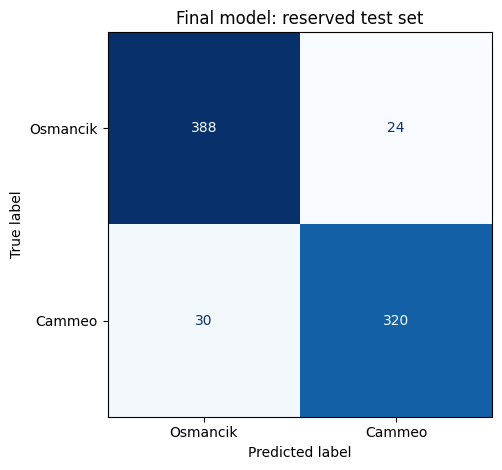

Osmancik predicted as Cammeo: 24
Cammeo predicted as Osmancik: 30
Total variety mix-ups: 54 of 762
Test rows exactly matching training feature rows: 0


In [14]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)

y_test = Y_test.map(label_map)
assert y_test.notna().all(), "Unexpected test labels: check the mapping."

y_pred = final_model.predict(X_test)
cammeo_probability = final_model.predict_proba(X_test)[:, 1]

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

test_results = pd.DataFrame({
    "Model": ["Majority baseline", best_name],
    "Accuracy": [accuracy_score(y_test, baseline_pred), accuracy_score(y_test, y_pred)],
    "Macro-F1": [f1_score(y_test, baseline_pred, average="macro"),
                 f1_score(y_test, y_pred, average="macro")]
})
display(test_results.round(4))
print("Selected-model ROC-AUC (Cammeo positive):",
      round(roc_auc_score(y_test, cammeo_probability), 4))
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Osmancik", "Cammeo"], digits=4))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["Osmancik", "Cammeo"]).plot(
    cmap="Blues", colorbar=False
)
plt.title("Final model: reserved test set")
plt.tight_layout()
plt.show()

print("Osmancik predicted as Cammeo:", cm[0, 1])
print("Cammeo predicted as Osmancik:", cm[1, 0])
print("Total variety mix-ups:", (y_test != y_pred).sum(), "of", len(y_test))

# Evaluation-only audit: check exact feature matches across the original split.
train_hashes = pd.util.hash_pandas_object(X_train, index=False)
test_hashes = pd.util.hash_pandas_object(X_test, index=False)
print("Test rows exactly matching training feature rows:",
      test_hashes.isin(train_hashes).sum())

### Evaluation discussion

The selected model achieves **92.91% accuracy**, **0.9286 macro-F1**, and **0.9823 ROC-AUC**. Test macro-F1 is close to validation (0.9297). Accuracy exceeds the training-majority baseline's **54.07%** test accuracy; differences in class proportions explain why this baseline differs from its training accuracy.

There are **54 errors out of 762 grains**: 24 Osmancik grains labelled Cammeo and 30 Cammeo grains labelled Osmancik. Cammeo's recall is **91.43%**, just behind Osmancik's recall (**94.17%**), so overall good results but there are still some missed grains in both directions. AUC measures ranking and not purity of sorted output.

No test predictor row exactly matches a training row in the audit. This does not exclude batch dependence. One random holdout is limited evidence; these test findings are reported without changing the model.

## 6. Final Thoughts

### Explain the fitted model

For logistic regression, each coefficient describes a change in the model's score for Cammeo when one scaled predictor increases, holding the others fixed. Positive values favour Cammeo; negative values favour Osmancik. Because features were standardised, coefficient magnitudes are expressed on comparable scale units. They are associations, not causal effects.

The code below inspects the chosen model directly. If a future training-only revision selects KNN, its explanation instead comes from the labels of the nearest training grains. It would be incorrect to use a logistic comparator's coefficients to explain KNN predictions.

,Coefficient
Area,-10.0239
Perimeter,-2.8459
Minor_Axis_Length,-2.3255
Eccentricity,-0.3151
Extent,0.0189
Major_Axis_Length,3.4035
Convex_Area,15.8697


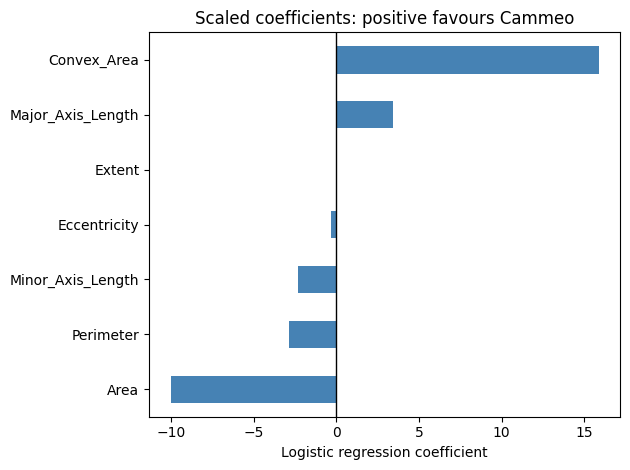

In [15]:
if best_name == "Logistic regression":
    coefficients = pd.Series(
        final_model.named_steps["model"].coef_[0],
        index=X_train.columns, name="Coefficient"
    )
    display(coefficients.sort_values().round(4).to_frame())
    coefficients.sort_values().plot.barh(color="steelblue")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Scaled coefficients: positive favours Cammeo")
    plt.xlabel("Logistic regression coefficient")
    plt.tight_layout()
    plt.show()
else:
    print("KNN predicts the majority variety among",
          final_model.named_steps["model"].n_neighbors,
          "nearby training grains, using standardised Euclidean distances.")

### Business conclusions and limitations

**The measurements can support variety identification within this dataset.** Against an always-Osmancik benchmark, the model makes just 54 mistakes on these 762 grains. That is a classification improvement, not measured financial savings.

Convex_Area has the largest positive coefficient, while Area has a large negative coefficient. Their 0.999 correlation means these opposing weights must be interpreted jointly, not as evidence that increasing grain area causes a change of variety. Major_Axis_Length also favours Cammeo in the fitted model; Extent's coefficient is near zero conditional on the other measurements. These are model-specific associations, not a stable causal importance ranking.

**Recommendation: a supervised pilot, not autonomous production sorting.** Let staff verify outputs and record both types of mix-up. First agree acceptable error rates and commercial costs with the processor; no such acceptance target was supplied. The observed 7.09% error rate may be unacceptable for strict variety-purity requirements.

Before operational use, evaluate newly collected labelled grains across suppliers, harvests and measuring equipment. The model covers only two varieties and will still choose one for an unfamiliar variety. Grain-level random splitting, unknown batch structure, and already-extracted measurements limit transfer to a factory. Sensor extraction quality, throughput, installation cost and actual savings were not evaluated.

### References

- Mahdavi M. (Lecture slides) Gisma University of Applied Sciences.

### Dataset
- Pushkarna, C. n.d. *Rice Cammeo and Osmancik*. Kaggle. Available at: https://www.kaggle.com/datasets/chetalipushkarna/rice-cammeo-and-osmancik
- UCI Machine Learning Repository. 2019. *Rice (Cammeo and Osmancik)* [Dataset]. Available at: https://doi.org/10.24432/C5MW4Z 